# Introdução às Redes Neurais e Deep Learning

## O Perceptron Multicamada - Continuação

### Implementação vetorial de uma rede neural didática com três camadas

In [14]:
import numpy as np

# Xavier Normalized Initialization
def initWeights(in_size, out_size):
    return np.random.uniform(-1, 1, (in_size, out_size))*np.sqrt(6 /(in_size + out_size))

class NeuralNetwork:
    
    """ Os dados de entrada devem ter o formato de matrizes x[n_input,n_amostras]
    e y[n_output,n_amostras]"""
    
    def __init__(self,hidden_activation, output_activation,loss,
                 n_input, n_hidden, n_output):
        # Armazena o número de neurônios em cada camada
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_output = n_output
        
        # Armazena as funções de ativação para cada camada e a função custo
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.loss=loss
        
        # Inicializa as matrizes de pesos
        np.random.seed(42)
        self.w_h=initWeights(n_hidden,n_input)  
        self.w_o=initWeights(n_output,n_hidden) 
        self.bias_h=np.zeros((n_hidden, 1))
        self.bias_o=np.zeros((n_output, 1))
        
        # Evolução da função custo
        self.loss_history=[]
           
    def activation_function(self,f_activ,x):
        if f_activ=='linear':
            return 1.*x
        if f_activ=='sigmoid':
            return 1 / (1 + np.exp(-x))        
        if f_activ == 'tanh':
            return np.tanh(x)
        if f_activ == 'relu':
            return np.maximum(0,x)         
    
    def deriv_activ_function(self,f_activ,x):
        if f_activ=='linear':
            return 1.
        if f_activ=='sigmoid':
            fx = self.activation_function(f_activ,x)
            return fx * (1 - fx)
        if f_activ == 'tanh':
            fx = self.activation_function(f_activ,x)
            return 1-fx**2
        if f_activ == 'relu':
            return (x>0).astype(np.float64)
    
    def compute_loss(self,y, y_hat):

        if self.loss=='logloss':
            #Atenção: Se houver um termo nulo em y_hat o cálculo resultará inf.
            eps=1e-15
            y_hat=np.clip(y_hat,eps,1-eps)
            cost = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)).mean()
        if self.loss=='mse':
            cost=((y-y_hat)**2).mean()
        return np.squeeze(cost)
    
    def deriv_loss(self,y,y_hat):
        # derivada em relação a y_p
        m=len(y[0,:])
        if self.loss=='logloss':
            #Atenção: Se houver um termo nulo ou 1 em y_hat o cálculo resultará inf.
            eps=1e-15
            y_p=np.clip(y_hat,eps,1-eps)
            return (y_hat-y)/m/(y_hat*(1-y_hat))
        
        if self.loss=='mse':
            return -2*(y-y_hat)/m 
    
    def forward_propagation(self,x):
        
        z_h = np.dot(self.w_h, x) + self.bias_h
        output_h = self.activation_function(self.hidden_activation,z_h)
        z_o = np.dot(self.w_o, output_h) + self.bias_o
        y_hat = self.activation_function(self.output_activation,z_o)
        
        return z_h,z_o,output_h,y_hat
    
    def backward_propagation(self,x, y,z_h, z_o, output_h, y_hat):
        
        # Camada de saída
        # ================
        #dL/dYhat
        dYhat=self.deriv_loss(y,y_hat)
        #dL/dZo
        dz_o =dYhat*self.deriv_activ_function(self.output_activation,z_o)
        #dL/dWo
        dw_o = np.dot(dz_o, output_h.T)
        #dL/d_bias_o
        db_o = np.sum(dz_o, axis=1, keepdims=True)
        
        # Camada interna (hidden)
        # =======================       
        #dL/dZh
        dz_h = np.dot(self.w_o.T, dz_o) * self.deriv_activ_function(self.hidden_activation,z_h)
        #dL/dWh
        dw_h = np.dot(dz_h, x.T)
        #dL/d_bias_h
        db_h = np.sum(dz_h, axis=1, keepdims=True)
        
        return dw_h,dw_o,db_h,db_o
    
    def train(self,x, y, epochs=1000, learning_rate=0.1):
        
        for i in range(epochs):
            
            # Forward propagation e Custo.
            z_h,z_o,output_h,y_hat = self.forward_propagation(x)
            cost = self.compute_loss(y, y_hat)
            
            # Recupera o vetor gradiente=[dw_o,db_o,dw_h,db_h]
            dw_h,dw_o,db_h,db_o = self.backward_propagation(x, y,z_h,z_o, output_h, y_hat)
            
            # Atualiza os parâmetros com os gradientes computados (DG)           
            self.w_h-=learning_rate*dw_h        
            self.w_o-=learning_rate*dw_o
            self.bias_h-=learning_rate*db_h
            self.bias_o-=learning_rate*db_o
            
            if i % 100 == 0:
                print(f"Epoch {i}: Cost = {cost}")
            self.loss_history.append(cost)        
    
    def predict(self,x):
        _,_,_,y_hat= self.forward_propagation(x)
        return y_hat
    

#### **Operações matriciais na retropropagação**

Considere uma rede neural totalmente conectada com uma camada de entrada, uma camada oculta e uma camada de saída. Nesta implementação, cada coluna da matriz de entrada representa uma amostra. Assim, para um conjunto contendo $m$ amostras,

$$X \in \mathbb{R}^{n_i\times m},$$

onde $n_i$ é o número de entradas da rede.

De forma semelhante, a matriz contendo os valores desejados é

$$Y \in \mathbb{R}^{n_o\times m},$$

onde $n_o$ representa o número de neurônios da camada de saída.

Se a camada oculta possuir $n_h$ neurônios, as matrizes de pesos e os vetores de bias possuem as dimensões

$$W_h\in\mathbb{R}^{n_h\times n_i},\qquad b_h\in\mathbb{R}^{n_h\times 1},$$

e

$$ W_o\in\mathbb{R}^{n_o\times n_h},\qquad b_o\in\mathbb{R}^{n_o\times 1}.$$

##### **Propagação direta**

Na camada oculta, inicialmente é calculada a combinação linear
$$Z_h=W_hX+b_h.$$
Como
$$ W_h\in\mathbb{R}^{n_h\times n_i}\quad\text{e}\quad X\in\mathbb{R}^{n_i\times m},$$
temos
$$ Z_h\in\mathbb{R}^{n_h\times m}.$$
O vetor $b_h$ possui dimensão $n_h\times 1$ e é somado a todas as colunas de $W_hX$. No NumPy, essa operação é realizada automaticamente por *broadcasting*.

A saída da camada oculta é obtida aplicando a função de ativação elemento a elemento:
$$ H=f_h(Z_h),$$
de modo que
$$H\in\mathbb{R}^{n_h\times m}.$$
Para a camada de saída,
$$ Z_o=W_oH+b_o,$$
e
$$\widehat{Y}=f_o(Z_o).$$
Portanto,
$$Z_o,\widehat{Y}\in\mathbb{R}^{n_o\times m}.$$
A propagação direta pode, assim, ser resumida por
$$\boxed{X\longrightarrow Z_h=W_hX+b_h \longrightarrow H=f_h(Z_h) \longrightarrow Z_o=W_oH+b_o \longrightarrow \widehat{Y}=f_o(Z_o)}$$
##### **Retropropagação**

O objetivo da retropropagação é calcular as derivadas da função custo $L$ em relação a todos os parâmetros ajustáveis da rede:
$$ \frac{\partial L}{\partial W_o},\qquad \frac{\partial L}{\partial b_o}, \qquad \frac{\partial L}{\partial W_h}, \qquad \frac{\partial L}{\partial b_h}.$$
Essas derivadas são calculadas começando pela saída da rede e seguindo no sentido inverso ao utilizado durante a propagação direta.

##### **Erro na camada de saída**
Inicialmente calcula-se
$$\frac{\partial L}{\partial \widehat{Y}}.$$
Em seguida, como
$$\widehat{Y}=f_o(Z_o),$$
a regra da cadeia fornece
$$ \frac{\partial L}{\partial Z_o} = \frac{\partial L}{\partial \widehat{Y}} \odot f'_o(Z_o),$$
onde $\odot$ representa o produto elemento a elemento.

É conveniente definir
$$\delta_o = \frac{\partial L}{\partial Z_o}.$$
Assim,
$$ \delta_o\in\mathbb{R}^{n_o\times m}.$$

No código, essa operação corresponde a

```python
dYhat = self.deriv_loss(y,y_hat)
dz_o = dYhat * self.deriv_activ_function(self.output_activation, z_o)
```

É importante observar que o operador `*` do NumPy realiza aqui um produto elemento a elemento, e não um produto matricial.

##### **Gradiente dos pesos da camada de saída**

Na propagação direta,

$$ Z_o=W_oH+b_o.$$

Para compreender a derivada em relação aos pesos, considere inicialmente um único elemento:

$$ z_{o,i}^{(k)} = \sum_j w_{o,ij}h_j^{(k)}+b_{o,i},$$

onde $k$ identifica uma amostra.

Consequentemente,

$$ \frac{\partial L}{\partial w_{o,ij}} = \sum_{k=1}^{m} \frac{\partial L}{\partial z_{o,i}^{(k)}} h_j^{(k)}.$$

Essa soma sobre todas as amostras pode ser escrita de forma matricial como

$$ \boxed{ \frac{\partial L}{\partial W_o} = \delta_o H^T }$$

pois

$$ \underbrace{\delta_o}_{n_o\times m} \underbrace{H^T}_{m\times n_h}=\underbrace{\frac{\partial L}{\partial W_o}} _{n_o\times n_h}.$$

No código,

```python
dw_o = np.dot(dz_o, output_h.T)
```

Portanto, a transposição de $H$ não é apenas uma necessidade para compatibilizar dimensões. Ela faz com que o erro associado a cada neurônio de saída seja combinado com a ativação de cada neurônio da camada anterior, somando automaticamente as contribuições das $m$ amostras.

##### **Gradiente do bias da camada de saída**

O mesmo bias é utilizado para todas as amostras. Portanto, sua derivada corresponde à soma das contribuições de todas elas:

$$\boxed{\frac{\partial L}{\partial b_o}=\sum_{k=1}^{m}\delta_o^{(k)}}$$

ou, no código,

```python
db_o = np.sum(dz_o, axis=1, keepdims=True)
```

A opção $\texttt{axis=1}$ realiza a soma ao longo das colunas, isto é, ao longo das amostras. A opção $\texttt{keepdims=True}$ preserva o resultado como uma matriz coluna de dimensão

$$ n_o\times1.$$

##### **Propagação do erro para a camada oculta**

Para continuar a retropropagação é necessário determinar quanto cada neurônio da camada oculta contribuiu para o erro observado na saída.

Como

$$ Z_o=W_oH+b_o,$$

o gradiente em relação às ativações da camada oculta é

$$ \boxed{ \frac{\partial L}{\partial H}=W_o^T\delta_o }$$

pois

$$ \underbrace{W_o^T}_{n_h\times n_o} \underbrace{\delta_o}_{n_o\times m} =\underbrace{\frac{\partial L}{\partial H}}_{n_h\times m}.$$

Esta expressão possui uma interpretação importante: $W_o^T$ transporta para trás o erro presente nos neurônios da camada de saída, distribuindo-o entre os neurônios da camada oculta segundo os pesos das conexões.

Como

$$ H=f_h(Z_h),$$

aplicamos novamente a regra da cadeia:

$$ \frac{\partial L}{\partial Z_h}=\frac{\partial L}{\partial H}\odot f'_h(Z_h).$$

Definindo

$$\delta_h=\frac{\partial L}{\partial Z_h},$$

obtemos

$$\boxed{\delta_h=\left(W_o^T\delta_o\right)\odot f'_h(Z_h)}$$

que corresponde diretamente à linha

```python
dz_h = np.dot(self.w_o.T, dz_o) * 
       self.deriv_activ_function(self.hidden_activation,z_h)
```

do programa.

##### **Gradiente dos pesos da camada oculta**

Finalmente, como

$$ Z_h=W_hX+b_h,$$ 

o mesmo raciocínio utilizado na camada de saída fornece

$$\boxed{\frac{\partial L}{\partial W_h}=\delta_hX^T}$$

pois

$$ \underbrace{\delta_h}_{n_h\times m} \underbrace{X^T}_{m\times n_i}=\underbrace{\frac{\partial L}{\partial W_h}}_{n_h\times n_i}.$$

No código,
```python
dw_h = np.dot(dz_h, x.T)
```

e, para o bias,

$$ \boxed{\frac{\partial L}{\partial b_h}=\sum_{k=1}^{m}\delta_h^{(k)}}$$

implementado por

```python
db_h = np.sum(dz_h, axis=1, keepdims=True)
```

##### **Resumo matricial da retropropagação**

Toda a retropropagação desta rede pode ser resumida nas seguintes equações:

$$ \boxed{\delta_o=\frac{\partial L}{\partial\widehat{Y}}\odot f'_o(Z_o)}$$

$$\boxed{\frac{\partial L}{\partial W_o}=\delta_oH^T}$$

$$\boxed{\frac{\partial L}{\partial b_o}=\sum_{\text{amostras}}\delta_o}$$

$$\boxed{\delta_h=(W_o^T\delta_o)\odot f'_h(Z_h)}$$

$$ \boxed{\frac{\partial L}{\partial W_h}=\delta_hX^T}$$

$$\boxed{\frac{\partial L}{\partial b_h}=\sum_{\text{amostras}}\delta_h}$$

Pode-se observar uma estrutura comum para uma camada qualquer:

$$\boxed{
\frac{\partial L}{\partial W}=\delta(\text{entrada da camada})^T}$$

e o erro propagado para a camada anterior possui a forma

$$\boxed{\delta_{\mathrm{anterior}}=\left(W^T\delta_{\mathrm{atual}}\right)\odot f'(Z_{\mathrm{anterior}})}$$

Essas duas expressões constituem a essência matricial do algoritmo de retropropagação.

##### **Atualização dos parâmetros**

Depois que os gradientes são calculados, os parâmetros são atualizados pelo método do gradiente descendente:

$$W_h\leftarrow W_h-\eta\frac{\partial L}{\partial W_h},$$

$$W_o\leftarrow
W_o-\eta\frac{\partial L}{\partial W_o},$$

$$b_h\leftarrow b_h-\eta\frac{\partial L}{\partial b_h},$$

$$ b_o \leftarrow b_o-\eta\frac{\partial L}{\partial b_o},$$

onde $\eta$ representa a taxa de aprendizagem.

Portanto, embora a retropropagação seja frequentemente apresentada como um algoritmo complexo, sua implementação matricial nesta rede é formada essencialmente por três tipos de operações:
1. Produtos elemento a elemento, usados na regra da cadeia;
2. Produtos matriciais, usados para calcular os gradientes;
3. Somas ao longo das amostras, usadas para os gradientes dos biases.

A utilização de matrizes permite realizar simultaneamente os cálculos correspondentes a todos os neurônios e a todas as amostras do conjunto de treinamento.

Epoch 0: Cost = 0.8384608318610565
Epoch 100: Cost = 0.1330666902924728
Epoch 200: Cost = 0.07950380197857194
Epoch 300: Cost = 0.05717575081686898
Epoch 400: Cost = 0.0423765916372902
Epoch 500: Cost = 0.03262342323279572
Epoch 600: Cost = 0.025965484597432493
Epoch 700: Cost = 0.021293652747258807
Epoch 800: Cost = 0.017881276611483872
Epoch 900: Cost = 0.01529961899308991
Epoch 1000: Cost = 0.013291373516348716
Epoch 1100: Cost = 0.011698762469509166
Epoch 1200: Cost = 0.010409387415631247
Epoch 1300: Cost = 0.009350767262865054
Epoch 1400: Cost = 0.008467941447332558
Epoch 1500: Cost = 0.007720217940628274
Epoch 1600: Cost = 0.007082488327612562
Epoch 1700: Cost = 0.006533257511849794
Epoch 1800: Cost = 0.006056279670874309
Epoch 1900: Cost = 0.005638384242153295
Epoch 2000: Cost = 0.005269661439137146
Epoch 2100: Cost = 0.004942079213570714
Epoch 2200: Cost = 0.004649257492064495
Epoch 2300: Cost = 0.0043857398585425604
Epoch 2400: Cost = 0.004147637681314435
Epoch 2500: Cost = 0.

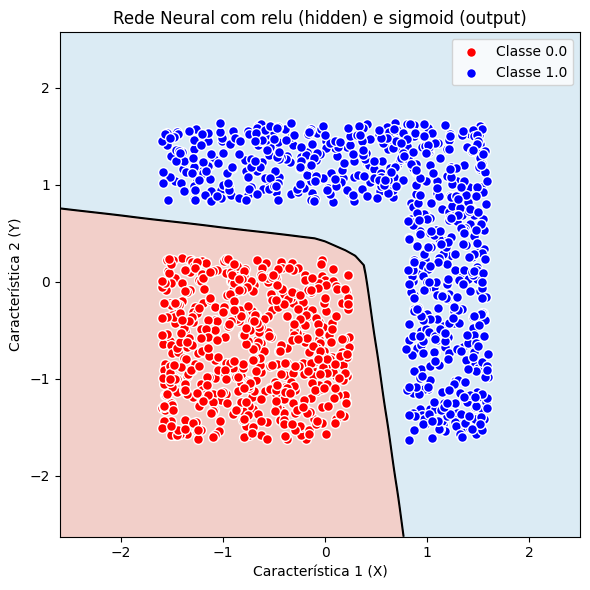

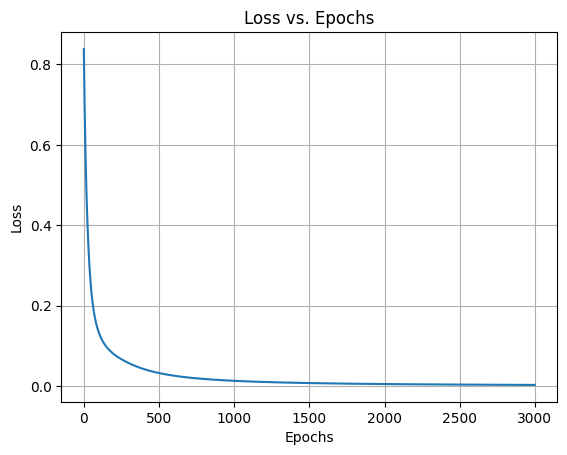

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


def plot_decision_boundaries(model, X, y, title="Fronteiras de Decisão da Rede Neural"):
    """
    Plota os dados e as fronteiras de decisão criadas pelo modelo.
    
    Parâmetros:
    - model: rede neural treinada
    - X: dados de entrada
    - y: rótulos (classes) dos dados
    - title: título do gráfico
    """
    # Define os limites do gráfico com base nos dados
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Cria uma grade para visualizar as fronteiras de decisão
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Achata a grade em 2 arrays e concatena as colunas convertendo 
    # em um array onde cada item são as coordenadas 2D dos pontos.
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Aplicaro modelo para cada ponto na grade
    Z = np.zeros(grid_points.shape[0])
    for i, point in enumerate(grid_points):       
        Z[i] = model.predict(point.reshape(2,1)).item()
    
    # Reformata Z para o formato 2D da grade
    Z = Z.reshape(xx.shape)
    
    # Plota as fronteiras de decisão e os pontos
    plt.figure(figsize=(6,6))
    levels=[-0.5,0.49,0.51,1.9]
    plt.contourf(xx, yy, Z,levels,alpha=0.3, cmap=plt.cm.RdBu)
    plt.contour(xx, yy, Z,levels,linewidths=1, colors='black')  
    
    # Plota os pontos de dados
    colors = ['red', 'blue']
    for i in np.unique(y):
        plt.scatter(X[y==i, 0], X[y==i, 1], 
                    label=f"Classe {i}", 
                    color=colors[int(i)], 
                    edgecolor='white', 
                    s=50)
    
    plt.title(title)
    plt.xlabel('Característica 1 (X)')
    plt.ylabel('Característica 2 (Y)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    

np.random.seed(0)
n = 1550
Xt1 = np.random.uniform(low=[0, 0], high=[4, 4], size=(n,2))
drop = (Xt1[:, 0] < 3) & (Xt1[:, 1] < 3)# pontos x<3 e y < 3
Xt1 = Xt1[~drop]
yt1= np.ones(len(Xt1))# elimina os pontos selecionados

Xt2 = np.random.uniform(low=[0, 0], high=[4, 4], size=(n,2))
drop = (Xt2[:, 0] > 2.3) | (Xt2[:, 1] > 2.3)

Xt2 = Xt2[~drop]
yt2= np.zeros(len(Xt2))

X4 = np.concatenate([Xt1, Xt2])
y4 = np.concatenate([yt1, yt2])

scaler = StandardScaler()
X4 = scaler.fit_transform(X4)
m=len(X4[:,0])
x=X4.T
y=y4.reshape(1,m)
 

epochs=3000
learning_rate=0.1
n_input=x.shape[0]
n_hidden=16
n_output=1
hidden_activation='relu'
output_activation='sigmoid'
loss='logloss'

model= NeuralNetwork(hidden_activation, output_activation,loss, n_input, n_hidden, n_output)
model.train(x, y,epochs, learning_rate)
    
plot_decision_boundaries(model, X4, y4, 
    f"Rede Neural com {hidden_activation} (hidden) e {output_activation} (output)")   

plt.figure()    
epoch=np.arange(epochs)
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')  
plt.show()  